In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, generate_correlated_copula_sources, addWGN, ProjectRowstoL1NormBall
from bss.LDMIBSS import LDMIBSS

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
# np.random.seed(400)
seed = np.random.randint(5000000)
np.random.seed(seed)
print("seed is ", seed)
N = 10000
NumberofSources = 5
NumberofMixtures = NumberofSources + 10

S = generate_correlated_copula_sources(
    rho=0.0,
    df=4,
    n_sources=NumberofSources,
    size_sources=N,
    decreasing_correlation=True,
)
S = 4 * S - 2
S = ProjectRowstoL1NormBall(S.T).T
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  1060996
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 30.002225934569168


(array([0.09639175, 0.0991668 , 0.09726199, 0.09952036, 0.09603785]),
 array([0.39971316, 0.64747688, 0.47784416, 0.43539859, 0.71579335,
        0.25928652, 0.36438922, 0.84972748, 1.0667292 , 0.26511796,
        0.87288498, 0.10631279, 0.50628947, 0.80776968, 0.63770765]))

# Hyperparameters

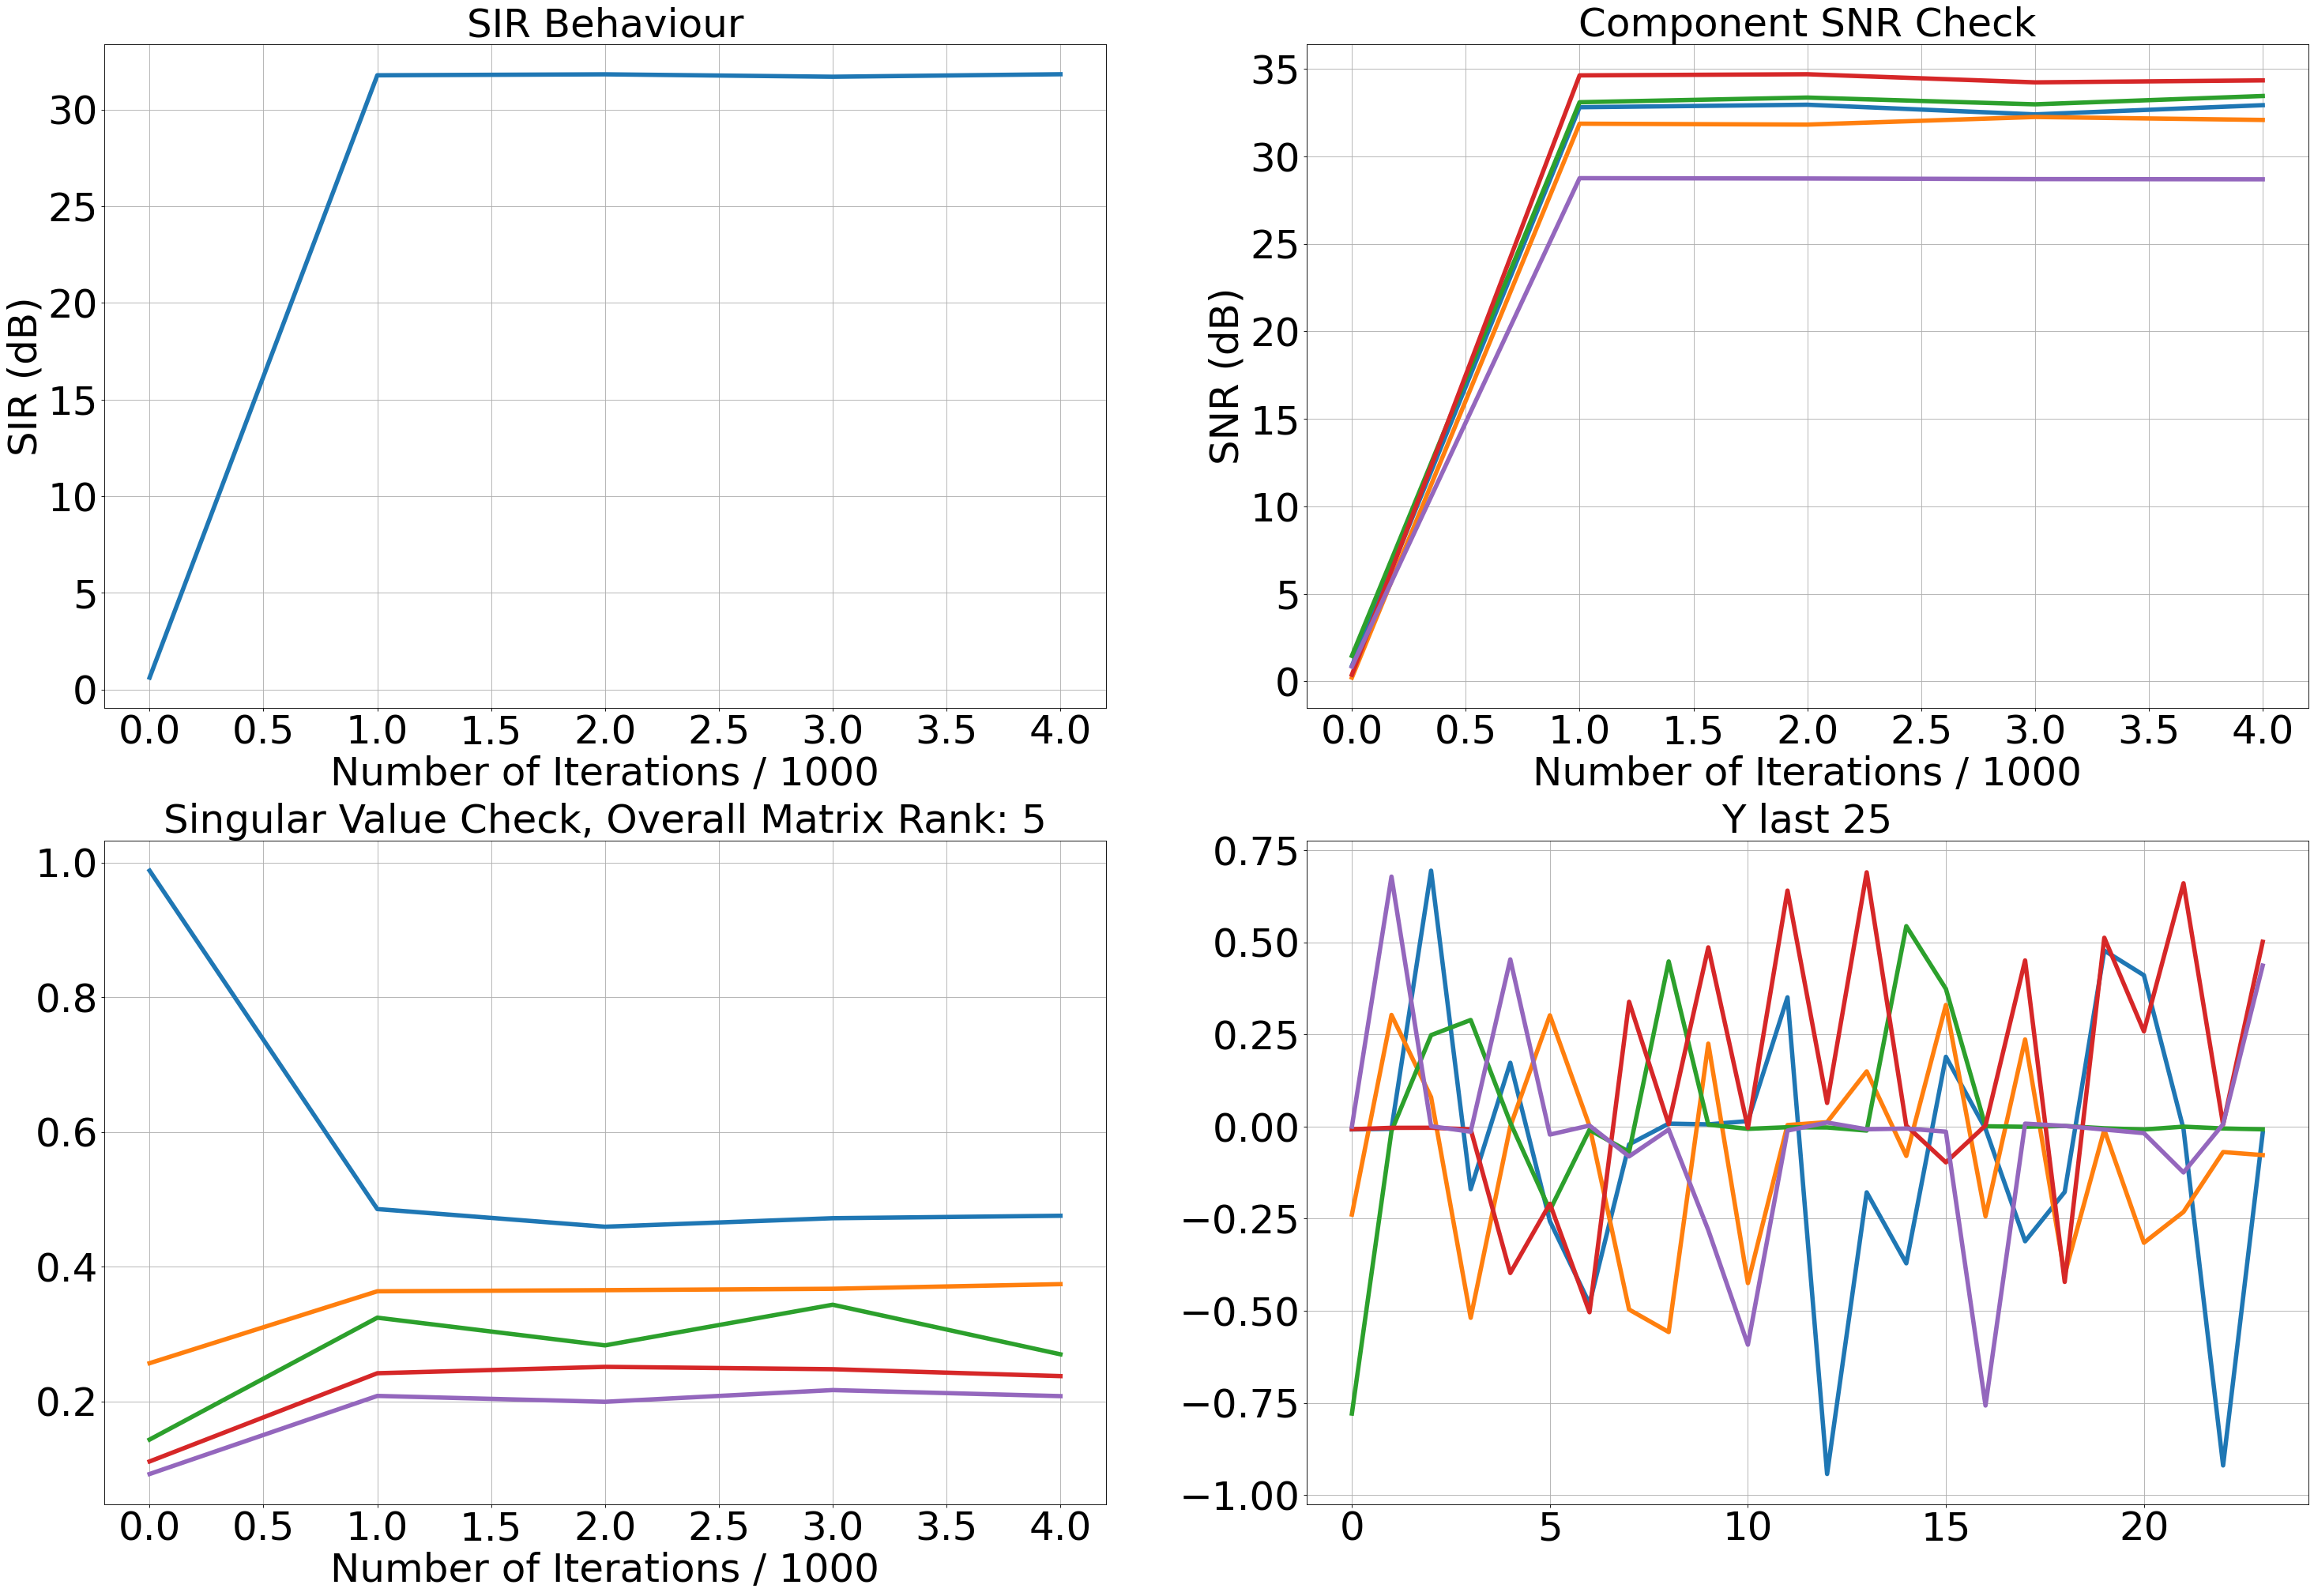

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:21<00:00, 61.10it/s]


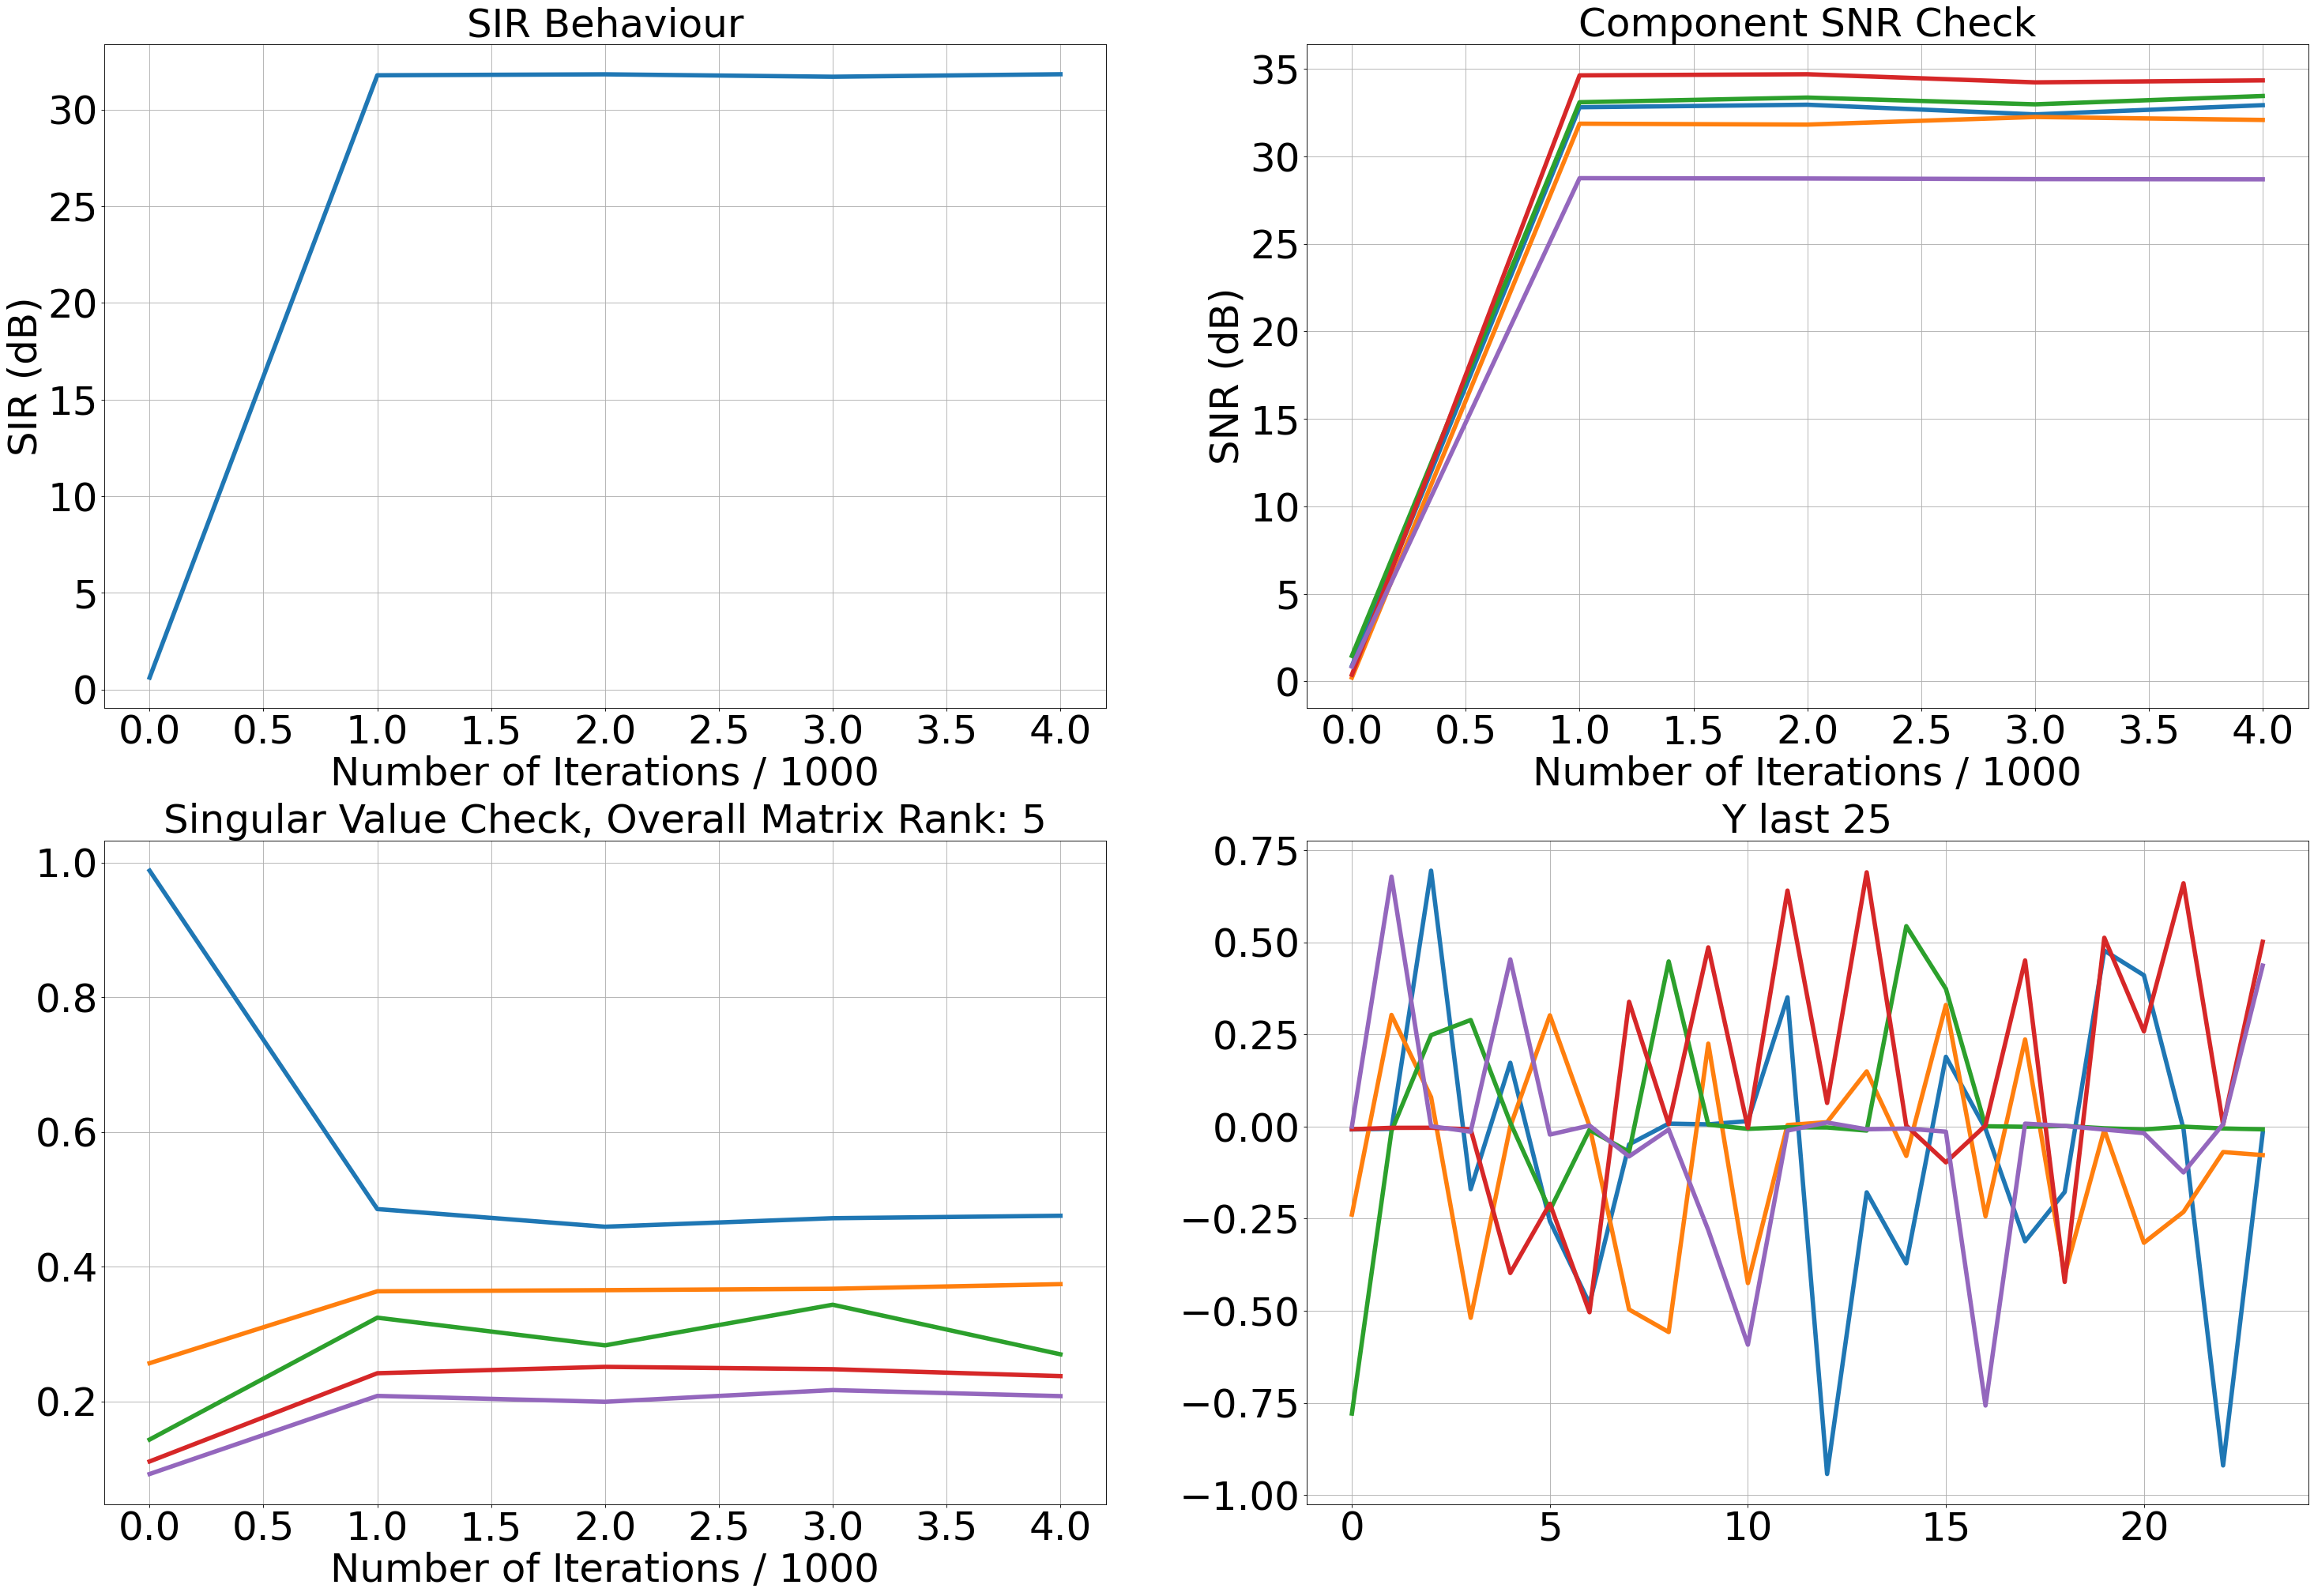

In [3]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "sparse",
                "method" : "correlation",
                ### Optimization parameters and Learning rates 
                "mu_y_start" : 100,
                "mu_y_rule" : "divide_by_root_index",
                "epsilon" : 1e-5,
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 1000,
                "plot_debug_during_training" : True,
}
model = LDMIBSS(**hyperparam_dict)
model.fit(X)

In [4]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 31.76757200389551
Component Signal-to-Noise-Ratio (SNR) Values : [32.74834683 31.91046467 33.67149052 34.21489892 28.67366862]



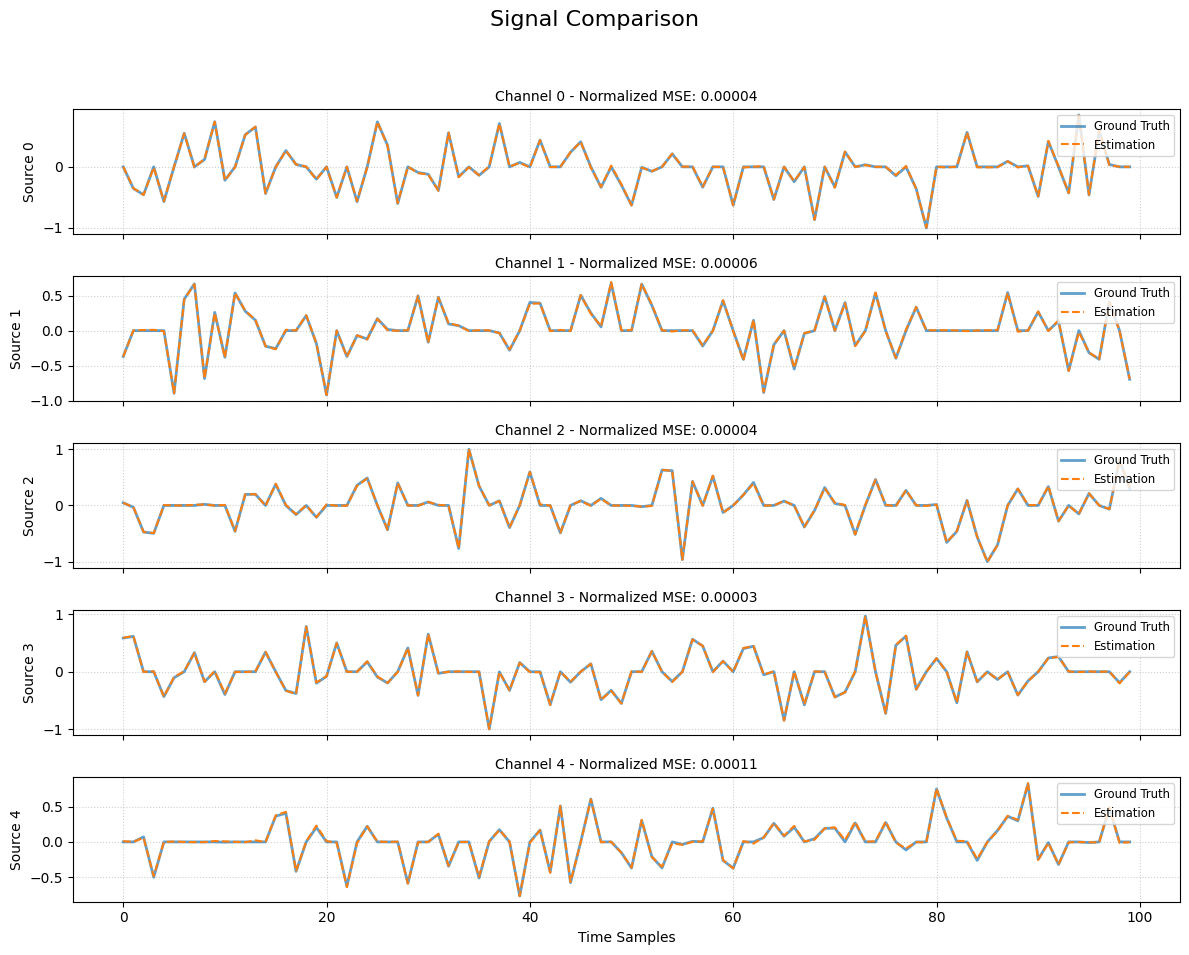

In [5]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])